In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import xndbc
from helpers import compute_data_coverage, plot_stations

### Parse all NDBC buoy observations

In [2]:
# Get all NDBC buoy stations
buoy_stations = xndbc.list_available(mode=None)

### Plot buoy locations

Text(0.5, 1.0, 'All NDBC Buoys')

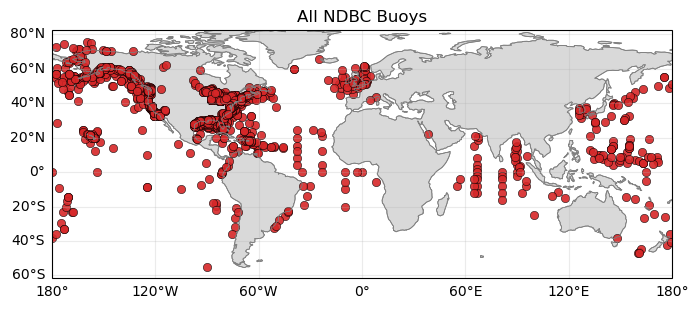

In [6]:
fig, ax = plot_stations(buoy_stations, add_labels = False)
ax.set_title("All NDBC Buoys")

### Filter for California buoys

Text(0.5, 1.0, 'All NDBC Buoys near California')

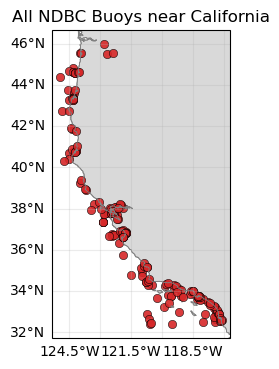

In [7]:
# Filter for California stations
california_buoys = xndbc.list_available(
    mode=None,
    lon_min=-125,
    lon_max=-115,
    lat_min=20,
    lat_max=46,
)
fig, ax = plot_stations(california_buoys, add_labels = False)
ax.set_title("All NDBC Buoys near California")

### Query all available data for California buoys between 1998 and 2000

In [ ]:
# Define years to retrieve data for
years = range(1998, 2000)

# Get list of California station IDs
station_list = california_buoys.station_id.values.tolist()

# Fetch historical data using the public xarray API
data = xndbc.fetch_data(
    station_ids=station_list,
    years=years,
    sample_rate="M",  # Monthly averages
)

coverage = compute_data_coverage(data)

Fetching stations: 100%|██████████| 192/192 [00:03<00:00, 60.66station/s] 


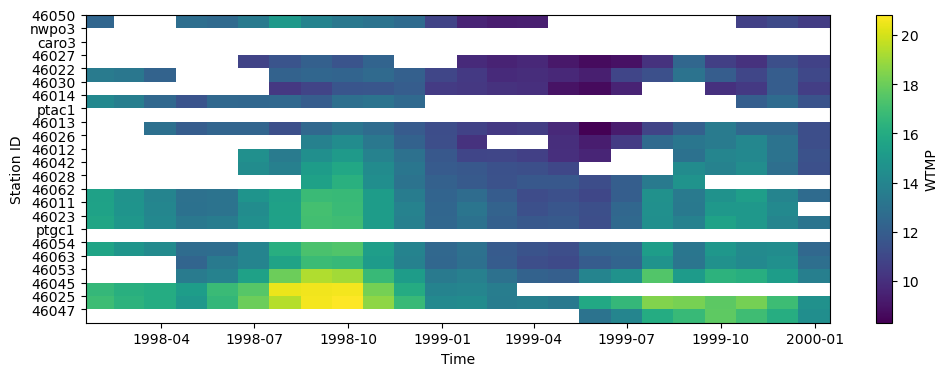

In [ ]:
sorted_data = data.sortby("latitude")

station_idx = np.arange(len(sorted_data["WTMP"].station_id))

plt.figure(figsize=(12, 4))
plt.pcolormesh(sorted_data["WTMP"].time, station_idx, sorted_data["WTMP"], cmap="viridis", shading="auto")
plt.yticks(station_idx + 0.5, sorted_data["WTMP"].station_id.values)
plt.xlabel("Time"); plt.ylabel("Station ID"); plt.colorbar(label="WTMP")
plt.show()

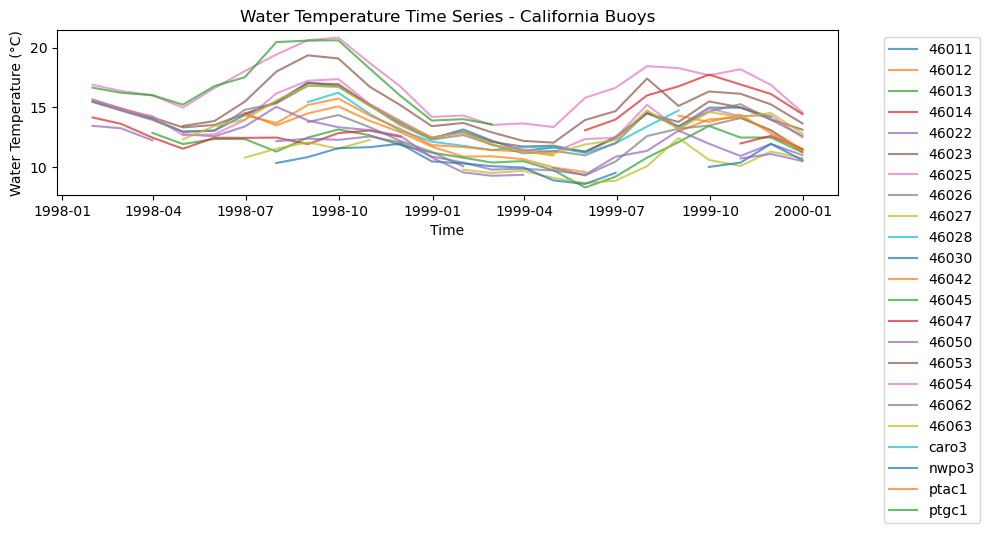

In [ ]:
# Plot water temperature time series for all California buoys
fig, ax = plt.subplots(figsize=(10, 4))
for station in data["station_id"]:
    ax.plot(data.time, data.WTMP.sel(station_id=station), label=station.values, alpha=0.7)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel("Time")
ax.set_ylabel("Water Temperature (°C)")
ax.set_title("Water Temperature Time Series - California Buoys")
plt.tight_layout()

Text(0.5, 1.0, 'Water Temperature Data Coverage - California Buoys')

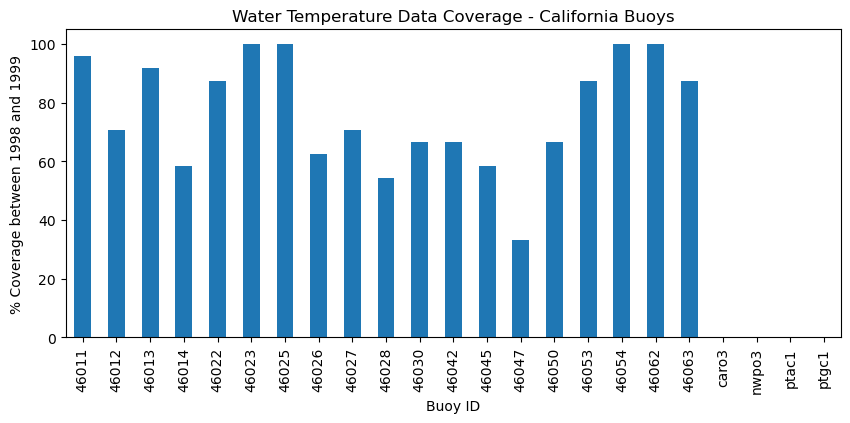

In [ ]:
# Plot data coverage for each station
fig, ax = plt.subplots(figsize=(10, 4))
coverage["WTMP_coverage"].to_series().plot.bar(ax=ax)
ax.set_xlabel("Buoy ID")
ax.set_ylabel(f"% Coverage between {years[0]} and {years[-1]}")
ax.set_title("Water Temperature Data Coverage - California Buoys")

In [ ]:
# Save the dataset to NetCDF file
# data.to_netcdf("NDBC_California_Daily.nc")
# print(f"Saved data for {len(data.station_id)} California buoys to NDBC_California_Daily.nc")